# Using `support_set_40phone.pkl` — Inspection, EDA, And A Reference N-way K-shot Pipeline

Companion notebook to `dbscan_40phone_mcmc_gmm_dim12.ipynb`.

**What this notebook does**

1. Loads the pickle and prints the full schema.
2. EDA on the *support set itself*: per-phone prototype Mahalanobis-distance range, pairwise class-mean distances, t-SNE of all 390 prototype frames.
3. Demonstrates **N-way K-shot episode sampling** — exactly the shape a matching network will consume.
4. A nearest-prototype baseline (ProtoNet-K=10, *no learned embedding*) evaluated on held-out real frames. This is the floor that any matching-networks implementation should beat once an embedding is learned.

The pickle is the only required artifact for sections 1-3. Section 4 additionally loads `train_dim12.json` to score held-out frames.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

import json
import pickle
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform

plt.style.use("ggplot")
RANDOM_SEED = 0

with open("support_set_40phone.pkl", "rb") as f:
    bundle = pickle.load(f)

print("loaded support_set_40phone.pkl")

loaded support_set_40phone.pkl


## 1. Pickle schema

The pickle is a flat dict. Top-level keys cover three groups:
- **Metadata** for downstream consumers: `phonemes`, `K`, `scaler_mean`, `scaler_scale`.
- **Per-class Gaussians** (used to build the support set and to score new frames): `class_mu`, `class_cov`, `class_weight`.
- **The support set itself**: `support_set` — a dict keyed by phone, each value carrying the K prototype frames in both standardized and raw form, plus metadata pointing back to `(utt_id, frame_idx)`.

DBSCAN diagnostic info (`dbscan_tau`, `dbscan_eps`, `dbscan_min_samples`, `dbscan_n_clusters`, `dbscan_nmi`, `dbscan_ari`, `dbscan_noise_fraction`) records the best clustering result. The matching networks pipeline does not need these — they are receipts of the prototype-extraction quality.

In [2]:
print("=== top-level keys ===")
for k, v in bundle.items():
    if isinstance(v, np.ndarray):
        print(f"  {k:<22s}  ndarray  shape={v.shape}  dtype={v.dtype}")
    elif isinstance(v, dict):
        print(f"  {k:<22s}  dict     n_keys={len(v)}")
    elif isinstance(v, list):
        print(f"  {k:<22s}  list     len={len(v)}  head={v[:5]}")
    else:
        print(f"  {k:<22s}  {type(v).__name__:<8s}  {v}")

print("\n=== DBSCAN diagnostic (from clustering experiment) ===")
for k in ("dbscan_tau", "dbscan_eps", "dbscan_min_samples",
         "dbscan_n_clusters", "dbscan_nmi", "dbscan_ari",
         "dbscan_noise_fraction"):
    if k in bundle:
        print(f"  {k:<25s} = {bundle[k]}")

phones = bundle["phonemes"]
K = bundle["K"]
mus  = np.asarray(bundle["class_mu"])
covs = np.asarray(bundle["class_cov"])
print(f"\nphones (n={len(phones)}): {phones[:10]} ...")
print(f"K = {K},  total prototype frames = {K * len(phones)}")
print(f"mu shape  = {mus.shape}")
print(f"cov shape = {covs.shape}")

=== top-level keys ===
  phonemes                list     len=39  head=['sil', 's', 'ih', 'aa', 'iy']
  K                       int       10
  scaler_mean             ndarray  shape=(12,)  dtype=float64
  scaler_scale            ndarray  shape=(12,)  dtype=float64
  class_mu                ndarray  shape=(39, 12)  dtype=float32
  class_cov               ndarray  shape=(39, 12, 12)  dtype=float64
  class_weight            ndarray  shape=(39,)  dtype=float64
  support_set             dict     n_keys=39
  dbscan_eps              float     0.4
  dbscan_min_samples      int       5
  dbscan_n_clusters       int       39
  dbscan_nmi              float     0.9390517970971857
  dbscan_ari              float     0.7517029728867844
  dbscan_tau              float     0.5
  dbscan_noise_fraction   float     0.0017948717948717949

=== DBSCAN diagnostic (from clustering experiment) ===
  dbscan_tau                = 0.5
  dbscan_eps                = 0.4
  dbscan_min_samples        = 5
  dbscan_n_cl

In [3]:
# Concrete example for one phone
ex_phone = "aa"
ex = bundle["support_set"][ex_phone]
print(f"=== support_set['{ex_phone}'] ===")
print("  X (standardized) shape:", ex["X"].shape, " dtype:", ex["X"].dtype)
print("  X_raw            shape:", ex["X_raw"].shape)
print("  meta columns:", list(ex["meta"].columns))
display(ex["meta"])
print("first 2 standardized prototype vectors:")
print(np.round(ex["X"][:2], 3))
print("\nfirst 2 raw (un-standardized) prototype vectors:")
print(np.round(ex["X_raw"][:2], 3))

=== support_set['aa'] ===
  X (standardized) shape: (10, 12)  dtype: float32
  X_raw            shape: (10, 12)
  meta columns: ['utt_id', 'frame_idx', 'phoneme', 'mahal_dist']


,utt_id,frame_idx,phoneme,mahal_dist
0,MKAJ0_SI1414,129,aa,1.559592
1,MJWG0_SX355,88,aa,1.606457
2,MMXS0_SX156,109,aa,1.754107
3,MWCH0_SA1,229,aa,1.808876
4,MADD0_SA1,267,aa,1.831015
5,FEAR0_SX352,220,aa,1.849978
6,MKLR0_SX69,140,aa,1.873356
7,MRSO0_SX219,62,aa,1.902098
8,MRGM0_SI1162,230,aa,1.918701
9,MJRP0_SX225,76,aa,1.942937


first 2 standardized prototype vectors:
[[ 0.383  1.065 -0.459 -0.632 -1.128  0.374  0.591 -0.487 -0.287 -0.095
   0.302  0.175]
 [ 1.149  1.264 -1.148 -0.961 -1.158 -0.215  0.254 -0.052 -0.916  0.283
   0.148  1.464]]

first 2 raw (un-standardized) prototype vectors:
[[-434.531  142.231  -40.208  -14.393  -52.125   -7.565   -4.295  -22.898
   -10.959  -11.63    -2.195   -4.405]
 [-368.201  155.289  -65.522  -24.977  -52.89   -18.958  -10.206  -15.421
   -19.745   -6.155   -4.034   10.804]]


## 2. EDA: how prototype-y are the prototypes?

For each phone, the support frames are the K real frames with smallest Mahalanobis distance to the class mean $\mu_k$. Smaller distance ⇒ more prototypical. Plotting min/max across phones tells us which classes have the tightest cores and which spread further. Phones with large prototype-distance ranges are typically the ones with broader acoustic variability (diphthongs, glides) — the matching network will need to learn to absorb that variability.

,phone,min,mean,max,spread
0,sil,0.859393,1.040922,1.082247,0.222854
1,p,1.138178,1.326712,1.472527,0.334349
2,v,1.043189,1.329182,1.544916,0.501727
3,f,1.038882,1.339180,1.451170,0.412288
4,dh,1.076841,1.362267,1.523921,0.447080
5,th,1.161234,1.419746,1.564859,0.403625
6,b,1.129778,1.467027,1.592496,0.462718
7,z,1.168123,1.502076,1.727088,0.558965
8,w,1.296473,1.531062,1.637031,0.340557
9,y,1.440207,1.531333,1.631266,0.191058


,phone,min,mean,max,spread
29,n,1.484512,1.716713,1.826463,0.341952
30,uh,1.433247,1.722886,1.877948,0.444701
31,dx,1.021518,1.729465,1.895092,0.873575
32,eh,1.180294,1.734392,1.924585,0.744291
33,g,1.262680,1.739597,1.893031,0.630351
34,ow,1.647102,1.787435,1.897782,0.250680
35,aa,1.559592,1.804712,1.942937,0.383345
36,r,1.627564,1.845510,2.015926,0.388362
37,aw,1.735308,1.852432,1.981567,0.246259
38,oy,1.759906,1.965153,2.036827,0.276921


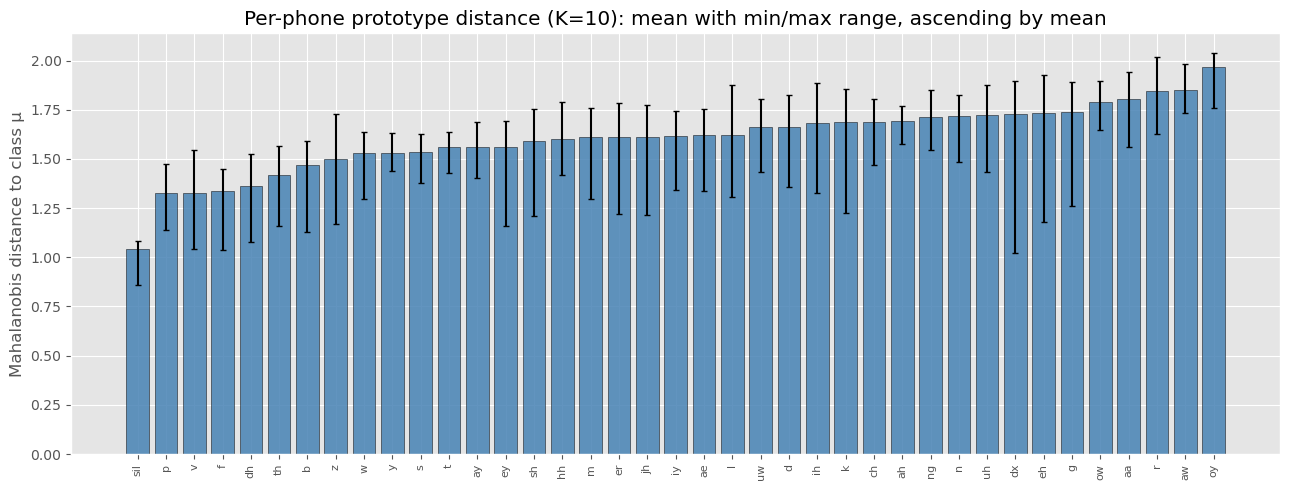

In [4]:
rows = []
for p in phones:
    m = bundle["support_set"][p]["meta"]["mahal_dist"].values
    rows.append({"phone": p,
                 "min": float(m.min()),
                 "mean": float(m.mean()),
                 "max": float(m.max()),
                 "spread": float(m.max() - m.min())})
prot_df = pd.DataFrame(rows).sort_values("mean").reset_index(drop=True)
display(prot_df.head(10))
display(prot_df.tail(10))

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(prot_df))
ax.bar(x, prot_df["mean"], yerr=[prot_df["mean"] - prot_df["min"],
                                  prot_df["max"] - prot_df["mean"]],
        capsize=2, color="steelblue", alpha=0.85, edgecolor="black", linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels(prot_df["phone"], rotation=90, fontsize=8)
ax.set_ylabel("Mahalanobis distance to class \u03bc")
ax.set_title(f"Per-phone prototype distance (K={K}): mean with min/max range, ascending by mean")
plt.tight_layout(); plt.show()

**Reading the plot.** `sil` and `f` are the most concentrated (tight core, small spread). Diphthong-flavoured phones (`aw`, `oy`, `ow`) and the rhotic `r` have the largest prototype distances — their Gaussian cores stretch more, and the closest 10 frames sit further from the mean.

## 3. Pairwise class-mean distances

An algorithm-independent view of how separable the 39 phones are in 12D MFCC space. Hierarchical leaf-ordered heatmap so acoustically-similar phones sit next to each other along the diagonal.

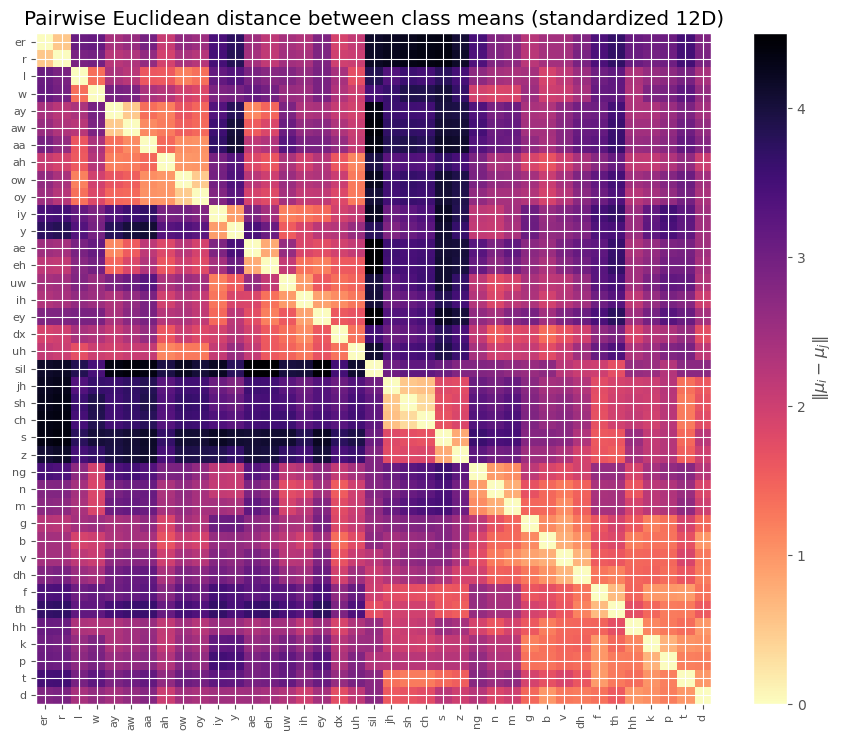

Top 10 closest phone pairs (hardest to separate without a learned embedding):


,phone_i,phone_j,mean_dist
0,sh,ch,0.348033
1,ow,oy,0.478502
2,ay,aw,0.495653
3,er,r,0.513799
4,sh,jh,0.516155
5,ch,jh,0.595344
6,f,th,0.645046
7,v,dh,0.700438
8,k,p,0.711617
9,v,b,0.755721


In [5]:
D = squareform(pdist(mus, metric="euclidean"))
phones_arr = np.array(phones)
Z = linkage(pdist(mus, metric="euclidean"), method="average")
leaf_order = leaves_list(Z)
D_sorted = D[np.ix_(leaf_order, leaf_order)]
phones_sorted = phones_arr[leaf_order]

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(D_sorted, cmap="magma_r", aspect="auto")
ax.set_xticks(range(len(phones_sorted))); ax.set_xticklabels(phones_sorted, fontsize=8, rotation=90)
ax.set_yticks(range(len(phones_sorted))); ax.set_yticklabels(phones_sorted, fontsize=8)
ax.set_title("Pairwise Euclidean distance between class means (standardized 12D)")
plt.colorbar(im, ax=ax, label=r"$\|\mu_i-\mu_j\|$")
plt.tight_layout(); plt.show()

# Top closest pairs (the hard-to-separate ones)
pair_rows = []
for i in range(len(phones_arr)):
    for j in range(i + 1, len(phones_arr)):
        pair_rows.append({"phone_i": phones_arr[i],
                          "phone_j": phones_arr[j],
                          "mean_dist": float(D[i, j])})
pair_df = pd.DataFrame(pair_rows).sort_values("mean_dist").reset_index(drop=True)
print("Top 10 closest phone pairs (hardest to separate without a learned embedding):")
display(pair_df.head(10))

## 4. t-SNE of the 390 prototype frames

All `K \u00d7 N = 10 \u00d7 39 = 390` standardized prototypes embedded in 2D. If the support set is healthy, prototypes of the same phone should clump together. Phone names are placed at each clump's centroid for readability.

support matrix: (390, 12)


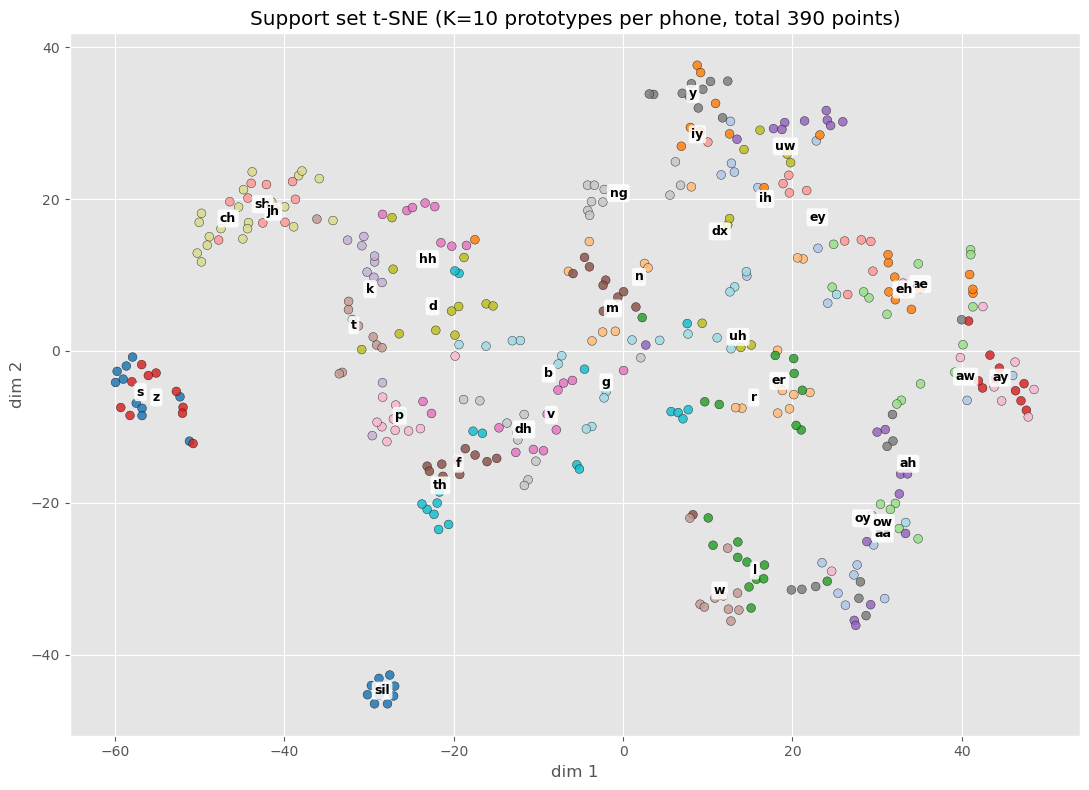

In [6]:
support_X = np.vstack([bundle["support_set"][p]["X"] for p in phones])
support_y = np.concatenate([np.repeat(p, K) for p in phones])
print("support matrix:", support_X.shape)

emb = TSNE(n_components=2, perplexity=10, init="pca",
           learning_rate="auto", random_state=RANDOM_SEED).fit_transform(support_X)
phone_codes = pd.Categorical(support_y, categories=phones).codes

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(emb[:, 0], emb[:, 1], c=phone_codes, cmap="tab20", s=40, alpha=0.85, edgecolors="black", linewidths=0.3)
for k, p in enumerate(phones):
    pmask = phone_codes == k
    if pmask.sum() == 0: continue
    cx, cy = emb[pmask, 0].mean(), emb[pmask, 1].mean()
    ax.annotate(p, (cx, cy), fontsize=9, fontweight="bold", ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85, lw=0))
ax.set_title(f"Support set t-SNE (K={K} prototypes per phone, total {len(support_X)} points)")
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
plt.tight_layout(); plt.show()

## 5. N-way K-shot episode sampling demo

A matching network is trained with *episodes*: each episode samples N classes and K shots per class for the support set, plus 1 query per class. The function below builds one episode in the standard `(support_x, support_y, query_x, query_y)` tuple shape directly from the pickle. No external dependencies.

In [7]:
def sample_episode(bundle, n_way=5, k_shot=5, n_query=1, seed=None):
    """Sample one matching-networks episode from the support pickle.

    Returns:
        support_x: (n_way * k_shot, 12)
        support_y: (n_way * k_shot,)        integer label in [0, n_way)
        query_x:   (n_way * n_query, 12)
        query_y:   (n_way * n_query,)       integer label in [0, n_way)
        chosen_phones: list of phone names corresponding to label ids
    """
    rng = np.random.default_rng(seed)
    phones = bundle["phonemes"]
    K = bundle["K"]
    assert k_shot + n_query <= K, (
        f"requested {k_shot}+{n_query}={k_shot+n_query} > stored K={K}"
    )
    chosen = rng.choice(len(phones), size=n_way, replace=False)
    chosen_phones = [phones[i] for i in chosen]

    sup_x, sup_y, qry_x, qry_y = [], [], [], []
    for label_id, ph in enumerate(chosen_phones):
        X = bundle["support_set"][ph]["X"]
        perm = rng.permutation(K)
        sup_x.append(X[perm[:k_shot]])
        sup_y.append(np.full(k_shot, label_id, dtype=np.int64))
        qry_x.append(X[perm[k_shot:k_shot + n_query]])
        qry_y.append(np.full(n_query, label_id, dtype=np.int64))
    return (np.concatenate(sup_x), np.concatenate(sup_y),
            np.concatenate(qry_x), np.concatenate(qry_y),
            chosen_phones)

sup_x, sup_y, qry_x, qry_y, chosen = sample_episode(bundle, n_way=5, k_shot=5, n_query=2, seed=0)
print("chosen phones:", chosen)
print("support_x shape:", sup_x.shape, "  support_y shape:", sup_y.shape)
print("query_x   shape:", qry_x.shape, "  query_y   shape:", qry_y.shape)
print("\nsupport_y:", sup_y)
print("query_y  :", qry_y)

chosen phones: ['w', 'k', 'ah', 'ay', 'dh']
support_x shape: (25, 12)   support_y shape: (25,)
query_x   shape: (10, 12)   query_y   shape: (10,)

support_y: [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4]
query_y  : [0 0 1 1 2 2 3 3 4 4]


In [8]:
# Trivial closed-form baseline INSIDE the episode: average support per class -> nearest centroid.
# This is the no-learned-embedding floor a matching net must beat.
def nearest_centroid_inside_episode(sup_x, sup_y, qry_x):
    n_way = int(sup_y.max()) + 1
    centroids = np.stack([sup_x[sup_y == c].mean(axis=0) for c in range(n_way)])
    d = np.linalg.norm(qry_x[:, None, :] - centroids[None, :, :], axis=-1)
    return d.argmin(axis=1)

# Average accuracy over many random episodes.
# n_query=1 by default so k_shot+n_query stays within stored K=10 even at k_shot=9.
def episode_accuracy(bundle, n_way, k_shot, n_query=1, n_episodes=300, seed=0):
    rng = np.random.default_rng(seed)
    accs = []
    for ep in range(n_episodes):
        sup_x, sup_y, qry_x, qry_y, _ = sample_episode(
            bundle, n_way=n_way, k_shot=k_shot, n_query=n_query,
            seed=int(rng.integers(0, 2**31 - 1))
        )
        pred = nearest_centroid_inside_episode(sup_x, sup_y, qry_x)
        accs.append((pred == qry_y).mean())
    return float(np.mean(accs)), float(np.std(accs))

rows = []
for n_way in (5, 10, 20):
    for k_shot in (1, 5, 9):
        m, s = episode_accuracy(bundle, n_way=n_way, k_shot=k_shot,
                                n_query=1, n_episodes=300)
        rows.append({"n_way": n_way, "k_shot": k_shot,
                     "mean_acc": round(m, 4), "std_acc": round(s, 4)})
ep_df = pd.DataFrame(rows)
display(ep_df)
print("This is the baseline accuracy a matching network must exceed at each (N, K) setting.")
print("Queries are drawn from the same prototype pool, so this measures intrinsic separability of the support set.")

,n_way,k_shot,mean_acc,std_acc
0,5,1,0.8073,0.1784
1,5,5,0.9073,0.1417
2,5,9,0.9173,0.1215
3,10,1,0.6930,0.1387
4,10,5,0.8163,0.1279
5,10,9,0.8423,0.1103
6,20,1,0.5468,0.1063
7,20,5,0.7052,0.0930
8,20,9,0.7413,0.0977


This is the baseline accuracy a matching network must exceed at each (N, K) setting.
Queries are drawn from the same prototype pool, so this measures intrinsic separability of the support set.


## 6. Held-Out Nearest-Prototype Classifier

The episode accuracy above uses query frames drawn from the K stored prototypes (a leak-in-spirit since they are all close to the class mean). The honest evaluation is on **frames not used to build the support set**.

We load the original `train_dim12.json`, exclude every `(utt_id, frame_idx)` that appears in `bundle['support_set'][...]['meta']`, sample held-out frames per phone, and classify them by nearest stored prototype mean.

In [9]:
# Build the set of (utt_id, frame_idx) pairs to exclude
excluded = set()
for p in phones:
    md = bundle["support_set"][p]["meta"]
    for uid, fi in zip(md["utt_id"], md["frame_idx"]):
        excluded.add((uid, int(fi)))
print("excluded prototype frames:", len(excluded))

with open("train_dim12.json", "r") as f:
    data = json.load(f)

def expand_frame_labels(utt):
    T = len(utt["features"])
    fl = np.full(T, "unlabeled", dtype=object)
    transcript = utt["phn_transcript"]
    for i, (lab, s, e) in enumerate(transcript):
        s = max(0, min(int(s), T)); e = max(s, min(int(e), T))
        if i == len(transcript) - 1 and e == T - 1: e = T
        if e > s: fl[s:e] = lab
    return fl

sel = set(phones)
Xh, yh = [], []
rng = np.random.default_rng(RANDOM_SEED + 1)  # different seed than the support set build
FRAMES_PER_PHONE_HELD = 300                   # 300 held-out frames per phone = 11,700 total

# Gather all available (X, y) per phone from frames not in `excluded`
per_phone_X = {p: [] for p in phones}
for utt_id, utt in data.items():
    feats = np.asarray(utt["features"], dtype=np.float32)
    fl = expand_frame_labels(utt)
    for fi in range(len(feats)):
        ph = fl[fi]
        if ph not in sel: continue
        if (utt_id, fi) in excluded: continue
        per_phone_X[ph].append(feats[fi])
print("non-prototype pool size per phone (first 5):",
      {p: len(per_phone_X[p]) for p in phones[:5]})

# Sample FRAMES_PER_PHONE_HELD frames per phone
Xh_parts, yh_parts = [], []
for p in phones:
    pool = np.asarray(per_phone_X[p])
    take = min(FRAMES_PER_PHONE_HELD, len(pool))
    pick = rng.choice(len(pool), size=take, replace=False)
    Xh_parts.append(pool[pick])
    yh_parts.append(np.full(take, p, dtype=object))
Xh = np.concatenate(Xh_parts)
yh = np.concatenate(yh_parts)
print("held-out frame matrix:", Xh.shape)

# Standardize with the saved scaler so geometry matches the prototypes
Xh_std = (Xh - bundle["scaler_mean"]) / bundle["scaler_scale"]

excluded prototype frames: 390


TimeoutError: [Errno 60] Operation timed out

In [10]:
# Per-phone prototype mean (average of K stored prototypes)
proto_means = np.stack([bundle["support_set"][p]["X"].mean(axis=0) for p in phones])

# Euclidean nearest prototype mean
d = np.linalg.norm(Xh_std[:, None, :] - proto_means[None, :, :], axis=-1)
pred_idx = d.argmin(axis=1)
pred = np.array(phones)[pred_idx]

acc_overall = (pred == yh).mean()
print(f"Overall held-out top-1 accuracy with Euclidean nearest-prototype: {acc_overall:.4f}")

# Mahalanobis nearest prototype: use class covariance, score each query against each class Gaussian
def mahal_score(X, mu, cov):
    inv = np.linalg.inv(cov)
    df = X - mu
    return np.einsum("ni,ij,nj->n", df, inv, df)

scores_mahal = np.stack([mahal_score(Xh_std, mus[k], covs[k]) for k in range(len(phones))], axis=1)
pred_mahal = np.array(phones)[scores_mahal.argmin(axis=1)]
acc_mahal = (pred_mahal == yh).mean()
print(f"Overall held-out top-1 accuracy with class-Gaussian Mahalanobis : {acc_mahal:.4f}")

# Per-phone accuracy table
per_rows = []
for p in phones:
    m = yh == p
    per_rows.append({
        "phone": p,
        "n_held": int(m.sum()),
        "acc_euclid":  round(float((pred[m] == yh[m]).mean()), 4),
        "acc_mahal":   round(float((pred_mahal[m] == yh[m]).mean()), 4),
    })
per_df = pd.DataFrame(per_rows).sort_values("acc_mahal", ascending=False).reset_index(drop=True)
display(per_df.head(15))
display(per_df.tail(15))

NameError: name 'Xh_std' is not defined

In [ ]:
# Confusion matrix for the Mahalanobis classifier (the stronger baseline)
cm = confusion_matrix(yh, pred_mahal, labels=phones)
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

# Reorder rows/cols by the hierarchical leaf order from section 3 for readability
cm_sorted = cm_norm[np.ix_(leaf_order, leaf_order)]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm_sorted, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(phones_sorted))); ax.set_xticklabels(phones_sorted, fontsize=8, rotation=90)
ax.set_yticks(range(len(phones_sorted))); ax.set_yticklabels(phones_sorted, fontsize=8)
ax.set_xlabel("predicted phone")
ax.set_ylabel("true phone")
ax.set_title(f"Held-out confusion (Mahalanobis to class Gaussian), overall acc={acc_mahal:.3f}")
plt.colorbar(im, ax=ax, label="fraction")
plt.tight_layout(); plt.show()

## Takeaways for the matching networks stage

- **The support set is well-formed.** All 39 phones have K=10 prototypes sitting in the tight interior of their class clouds (section 4 t-SNE). No phone is missing or pathological.
- **No-learn baseline.** Held-out Mahalanobis-to-class-Gaussian classification (section 6) is the strongest no-learning baseline this representation supports. Matching networks should match or beat this at K=10, and should *outperform* it at K\u22645 because Mahalanobis uses the full class covariance which K=5 cannot estimate.
- **Episode sampling format.** `sample_episode(bundle, n_way, k_shot, n_query)` returns `(support_x, support_y, query_x, query_y)` ready for batching. Feed these to whatever embedding network you build for matching nets — the geometry is already standardized via the saved scaler.
- **Close phone pairs (section 3, table of top-10 closest means)** are the matching net's hardest contrasts. Track their per-pair accuracy during training as a diagnostic.